In [ ]:
import pandas as pd

In [ ]:
with open('/content/conversa_full.txt') as file:
  lines = file.readlines()

In [ ]:
import re
import json

def extract_names(lines, output_path):
    names = set()
    pattern = re.compile(r" - (.*?):")

    for line in lines:
        match = pattern.search(line)
        if match:
            names.add(match.group(1).strip())

    original_names_mapping = {name: "" for name in names}

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(original_names_mapping, f, ensure_ascii=False, indent=2)

extract_names(lines, "names_mapping.json")

In [ ]:


with open('/content/names_mapping.json') as file:
    names_mapping = json.loads(file.read())

new_lines = []

for line in lines:
    for original, new in names_mapping.items():
        line = line.replace(original, new)
    new_lines.append(line)

lines = new_lines

In [ ]:
with open('/content/conversa_full_anonymized.txt', 'w', encoding="utf-8") as file:
  file.writelines(lines)

In [ ]:
import re
import pandas as pd

def parse_whatsapp_chat(file_path):
    pattern = re.compile(
        r"^(\d{2}/\d{2}/\d{4}) (\d{2}:\d{2}) - (.*?): (.*)"
    )

    data = []
    current_message = None

    def should_skip(msg):
        return "<Mídia oculta>" in msg

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            match = pattern.match(line)

            if match:
                # salva anterior (se não for mídia)
                if current_message and not should_skip(current_message["message"]):
                    data.append(current_message)

                date, time, author, message = match.groups()

                current_message = {
                    "date": date,
                    "time": time,
                    "author": author,
                    "message": message
                }
            else:
                if current_message:
                    current_message["message"] += "\n" + line

    # última mensagem
    if current_message and not should_skip(current_message["message"]):
        data.append(current_message)

    return pd.DataFrame(data)

df = parse_whatsapp_chat("conversa_full_anonymized.txt")
print(df.head())

         date   time  author  \
0  26/09/2024  17:06   Zelda   
1  26/09/2024  17:20  Altair   
2  26/09/2024  19:25    Thor   
3  26/09/2024  19:26  Altair   
4  26/09/2024  19:27   Zelda   

                                             message  
0  Saudades da diva, ela tá que nem os maias e os...  
1                                     Pose bem falsa  
2          Vocês não querem sair esse fim de semana?  
3  Tô muito afim não mano, tô meio caseiro esses ...  
4                                     Sair pra onde?  


## 1. Preparação

In [ ]:
import pandas as pd

# cria datetime real
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"], dayfirst=True)

# tamanho da mensagem
df["msg_length"] = df["message"].str.len()

# número de palavras
df["word_count"] = df["message"].str.split().str.len()

# hora do dia
df["hour"] = df["datetime"].dt.hour

# dia da semana
df["weekday"] = df["datetime"].dt.day_name()

## 2. Ranking de quem mais fal

In [ ]:
df.drop(df[df["author"] == "Meta AI"].index, inplace=True)
msg_count = df["author"].value_counts()

msg_count

,count
author,
Thor,9968
Zelda,8669
Wanda,7604
Altair,6255
Raven,4626
Neo,2802
Leia,2786
Mario,1213
Kratos,594


<Axes: title={'center': 'Mensagens por pessoa'}, xlabel='author'>

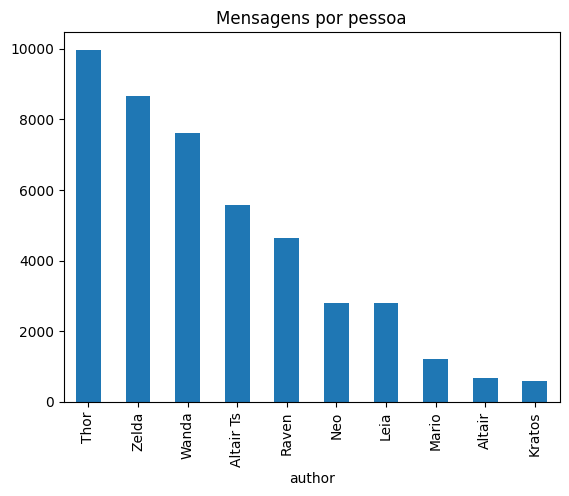

In [ ]:
msg_count.plot(kind="bar", title="Mensagens por pessoa")

## 3. Quem escreve mais textão vs quem é seco

In [ ]:
df.groupby("author")["msg_length"].mean().sort_values(ascending=False)

,msg_length
author,
Kratos,48.520202
Neo,30.917559
Mario,30.539984
Altair,29.096563
Wanda,27.980537
Leia,26.206030
Zelda,24.232207
Thor,22.987961
Raven,21.564202


<Axes: title={'center': 'Tamanho médio das mensagens'}, xlabel='author'>

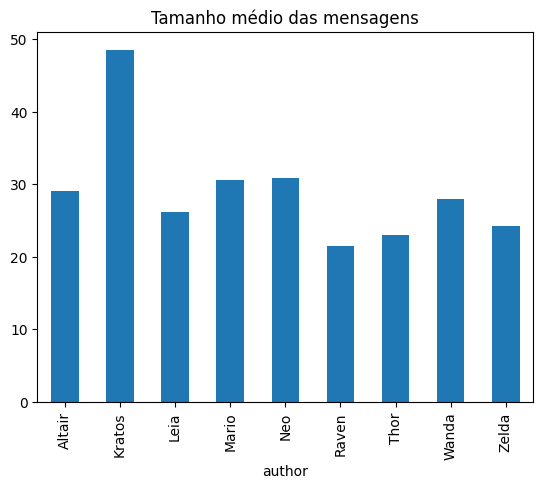

In [ ]:
df.groupby("author")["msg_length"].mean().plot(kind="bar", title="Tamanho médio das mensagens")

## 4. Quem manda mais mensagens seguidas

In [ ]:
df["prev_author"] = df["author"].shift()

df["is_sequence"] = df["author"] == df["prev_author"]

sequence_count = df.groupby("author")["is_sequence"].sum().sort_values(ascending=False)

sequence_count

,is_sequence
author,
Thor,4340
Zelda,3304
Wanda,2360
Altair,1954
Raven,1575
Neo,990
Leia,607
Mario,396
Kratos,129


## 5. Heatmap de atividade por hora

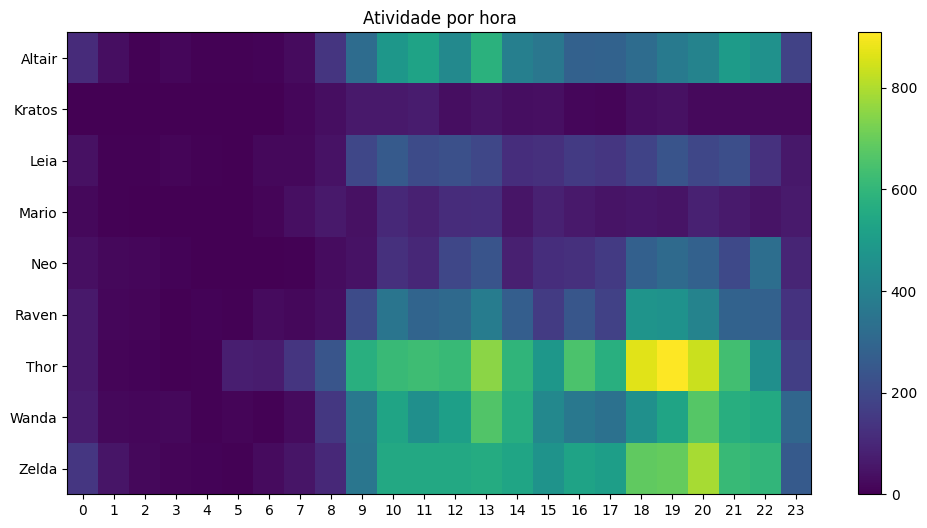

In [ ]:
import matplotlib.pyplot as plt

heatmap = df.pivot_table(index="author", columns="hour", values="message", aggfunc="count").fillna(0)

plt.figure(figsize=(12,6))
plt.imshow(heatmap, aspect="auto")
plt.colorbar()
plt.xticks(range(24), range(24))
plt.yticks(range(len(heatmap.index)), heatmap.index)
plt.title("Atividade por hora")
plt.show()

## 6. Dia da semana — quando o grupo vive

In [ ]:
weekday_count = df["weekday"].value_counts()

weekday_count

,count
weekday,
Wednesday,6933
Friday,6927
Saturday,6589
Tuesday,6492
Thursday,6254
Sunday,5698
Monday,5624


<Axes: title={'center': 'Mensagens por dia da semana'}, xlabel='weekday'>

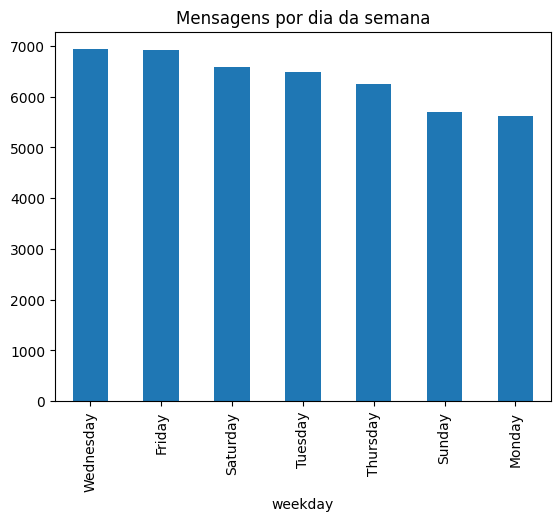

In [ ]:
weekday_count.plot(kind="bar", title="Mensagens por dia da semana")

## 7. Quem usa mais palavras por mensagem

In [ ]:
df.groupby("author")["word_count"].mean().sort_values(ascending=False)

,word_count
author,
Kratos,9.065657
Neo,6.074233
Mario,5.906018
Altair,5.507914
Wanda,5.470805
Leia,4.853195
Zelda,4.655554
Raven,4.410938
Thor,4.099819


## 8. Top palavras (sem lixo básico)

In [ ]:
from collections import Counter
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text

all_words = []

for msg in df["message"]:
    words = clean_text(msg).split()
    all_words.extend(words)

common = Counter(all_words).most_common(100)

common

[('que', 6712),
 ('eu', 4982),
 ('não', 4821),
 ('o', 4753),
 ('a', 4446),
 ('de', 4337),
 ('é', 3825),
 ('e', 3408),
 ('pra', 2830),
 ('ele', 2354),
 ('tá', 1998),
 ('do', 1998),
 ('com', 1924),
 ('já', 1799),
 ('um', 1761),
 ('no', 1604),
 ('só', 1568),
 ('mas', 1541),
 ('da', 1539),
 ('se', 1415),
 ('tu', 1403),
 ('vai', 1385),
 ('me', 1351),
 ('ela', 1280),
 ('na', 1261),
 ('tem', 1255),
 ('vou', 1232),
 ('meu', 1213),
 ('gente', 1201),
 ('em', 1180),
 ('uma', 1173),
 ('isso', 1136),
 ('tô', 1092),
 ('muito', 1002),
 ('mensagem', 1002),
 ('mais', 990),
 ('lá', 974),
 ('sim', 965),
 ('aqui', 949),
 ('por', 861),
 ('foi', 815),
 ('mesmo', 785),
 ('quem', 749),
 ('aí', 743),
 ('nem', 708),
 ('esse', 704),
 ('né', 698),
 ('agora', 680),
 ('editada', 661),
 ('ser', 631),
 ('minha', 624),
 ('amigo', 623),
 ('dele', 610),
 ('quero', 600),
 ('ainda', 576),
 ('sei', 560),
 ('bem', 559),
 ('kkkkkkkkkkkkkkkkkkkkkkkkk', 556),
 ('essa', 555),
 ('acho', 553),
 ('até', 544),
 ('assim', 539),
 ('t

## 9. Quem responde mais rápido

In [ ]:
df["response_time"] = df["datetime"].diff().dt.total_seconds()

response_by_author = df.groupby("author")["response_time"].mean().sort_values()

response_by_author

,response_time
author,
Neo,369.207709
Wanda,790.107838
Zelda,811.502077
Leia,849.389806
Raven,901.893645
Altair,1077.601918
Kratos,1217.979798
Thor,1514.909711
Mario,1780.560594


## 10. Gráfico de timeline

<Axes: title={'center': 'Mensagens por dia'}, xlabel='datetime'>

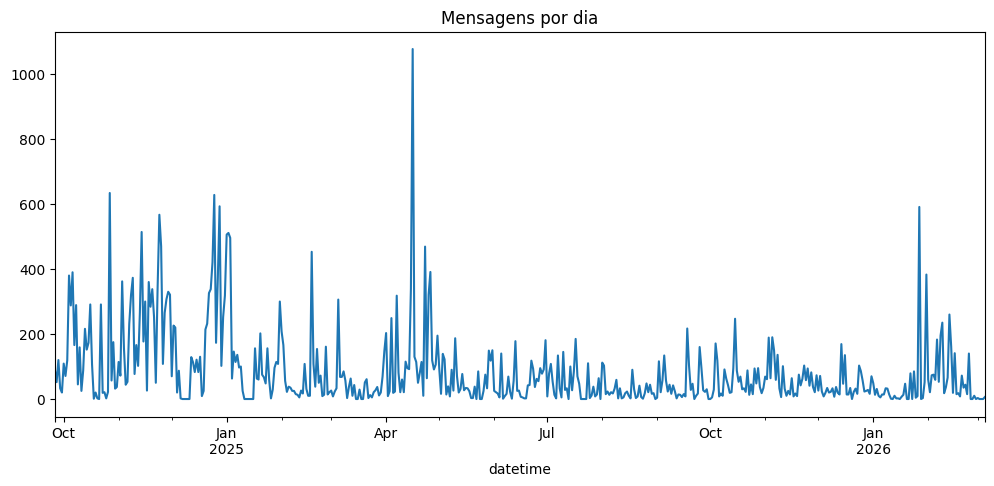

In [ ]:
df.set_index("datetime").resample("D")["message"].count().plot(figsize=(12,5), title="Mensagens por dia")

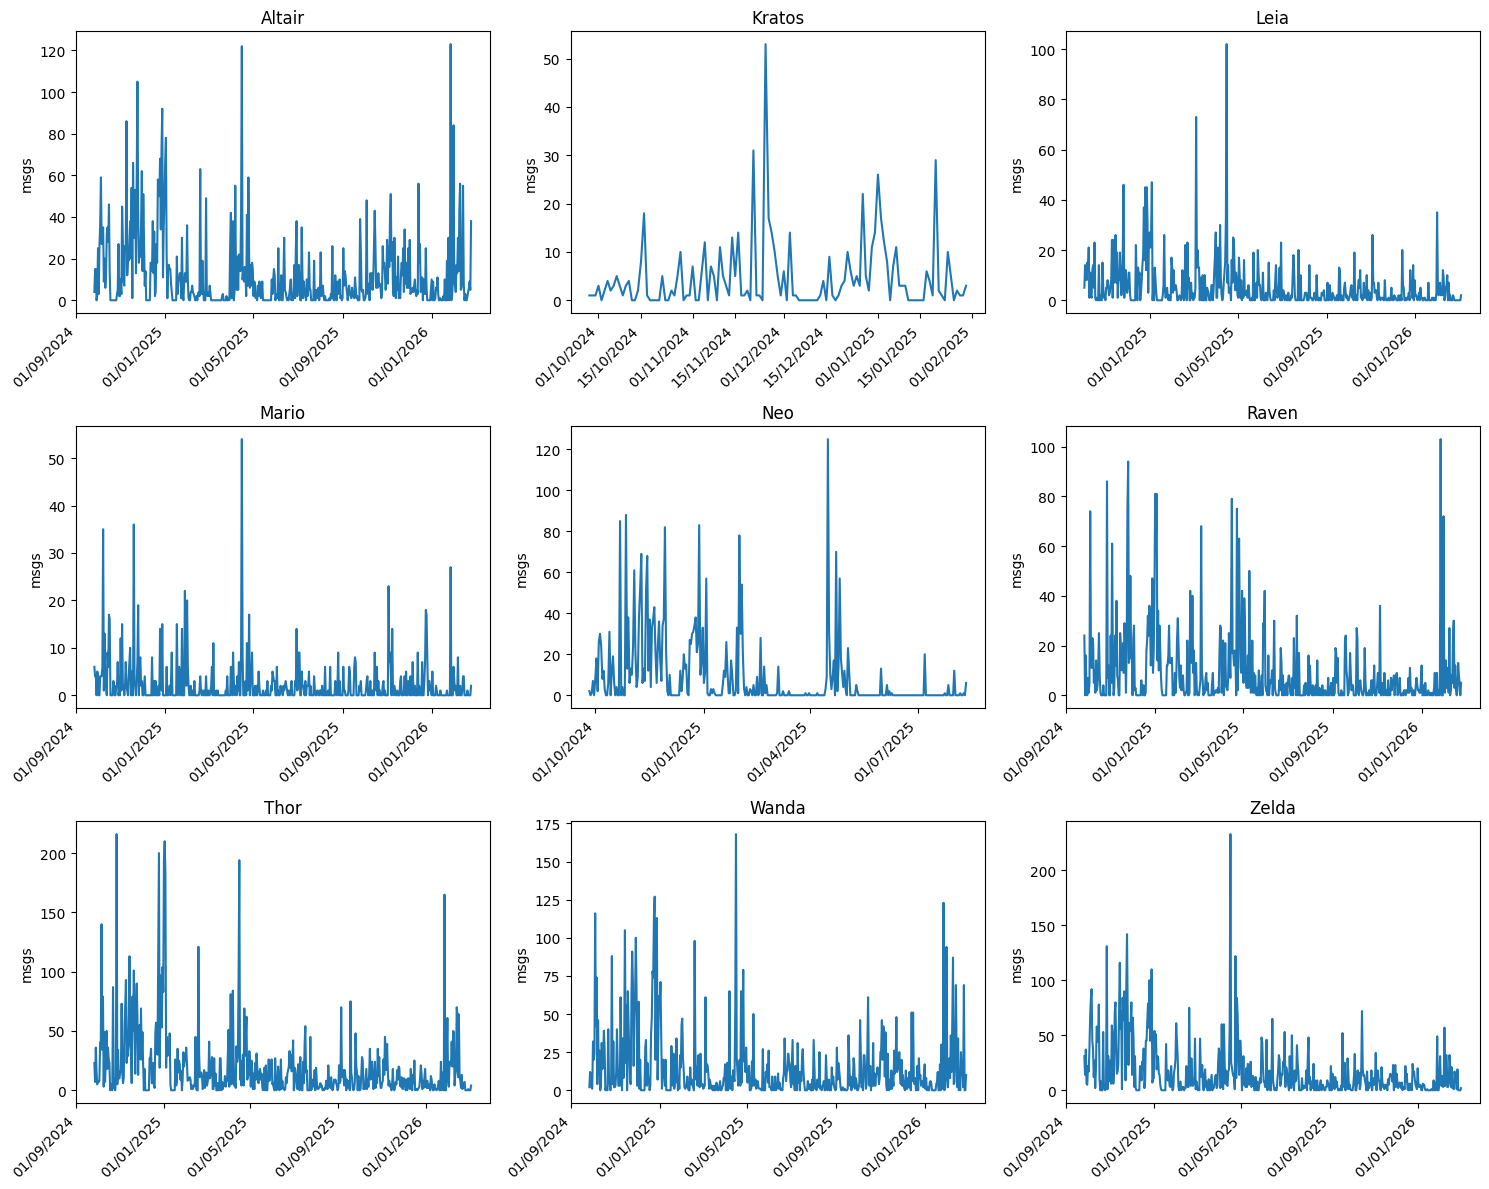

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math

timeline = (
    df.set_index("datetime")
      .groupby("author")
      .resample("D")["message"]
      .count()
      .reset_index()
)

authors = timeline["author"].unique()

cols = 3
rows = math.ceil(len(authors) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), sharex=False)
axes = axes.flatten()

for i, author in enumerate(authors):
    data = timeline[timeline["author"] == author]

    ax = axes[i]
    ax.plot(data["datetime"], data["message"])
    ax.set_title(author)
    ax.set_ylabel("msgs")

    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y"))

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 1. Extração correta de emojis

In [ ]:
import re
from collections import Counter

# regex robusta pra emojis
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # símbolos & pictogramas
    "\U0001F680-\U0001F6FF"  # transporte
    "\U0001F1E0-\U0001F1FF"  # bandeiras
    "\U00002700-\U000027BF"  # dingbats
    "\U0001F900-\U0001F9FF"  # suplementar
    "\U00002600-\U000026FF"  # misc
    "]+",
    flags=re.UNICODE
)

all_emojis = []

for msg in df["message"]:
    emojis = emoji_pattern.findall(msg)
    all_emojis.extend(emojis)

## 2. Frequência

In [ ]:
!pip install emoji regex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 23.9 MB/s eta 0:00:00


In [ ]:
import regex as re
from collections import Counter

# regex que entende emojis compostos corretamente
emoji_pattern = re.compile(r'\X', re.UNICODE)

def extract_emojis(text):
    return [
        grapheme for grapheme in emoji_pattern.findall(text)
        if any(char in emoji.EMOJI_DATA for char in grapheme)
    ]

import emoji

all_emojis = []

for msg in df["message"]:
    all_emojis.extend(extract_emojis(msg))

emoji_counts = Counter(all_emojis)

top_emojis = emoji_counts.most_common(400)
top_emojis

[('🤣', 1229),
 ('😂', 520),
 ('😔', 280),
 ('😭', 262),
 ('❤️', 185),
 ('🫦', 181),
 ('🤡', 81),
 ('🥹', 72),
 ('🥰', 63),
 ('🙏🏻', 62),
 ('🥲', 60),
 ('🎉', 47),
 ('👁️', 46),
 ('🥺', 44),
 ('🙂\u200d↕️', 38),
 ('😍', 37),
 ('🫶🏻', 35),
 ('🥳', 34),
 ('🤨', 33),
 ('🌚', 31),
 ('🤤', 27),
 ('♥️', 25),
 ('😢', 25),
 ('✨', 25),
 ('🗣️', 24),
 ('🫂', 22),
 ('🫶🏼', 21),
 ('🪬', 21),
 ('🫠', 20),
 ('👀', 19),
 ('🫣', 18),
 ('👄', 18),
 ('😆', 17),
 ('😋', 17),
 ('😹', 16),
 ('👏', 15),
 ('📍', 14),
 ('🙏🏽', 14),
 ('😌', 14),
 ('🤢', 14),
 ('😲', 14),
 ('😏', 14),
 ('😣', 13),
 ('🙂\u200d↔️', 13),
 ('💙', 13),
 ('🙏🏼', 13),
 ('😞', 12),
 ('😓', 12),
 ('🤧', 12),
 ('🎊', 12),
 ('😮\u200d💨', 10),
 ('🙄', 9),
 ('☹️', 9),
 ('🫰🏻', 9),
 ('😫', 9),
 ('🏳️\u200d🌈', 9),
 ('😱', 9),
 ('🤰🏻', 9),
 ('🤍', 8),
 ('🙌🏽', 8),
 ('✅️', 8),
 ('💔', 8),
 ('🤔', 7),
 ('😩', 7),
 ('😳', 7),
 ('🫶🏽', 7),
 ('🩷', 7),
 ('😕', 6),
 ('🤪', 6),
 ('👍🏻', 6),
 ('🐍', 6),
 ('🎶', 6),
 ('😡', 6),
 ('🧍🏻\u200d♀️', 5),
 ('🤮', 5),
 ('😠', 5),
 ('😴', 5),
 ('✅', 5),
 ('❌', 5),
 ('😮', 5),
 ('🥵',

## 3. Transformar em DataFrame (pra análise decente)

In [ ]:
import pandas as pd

emoji_df = pd.DataFrame(top_emojis, columns=["emoji", "count"])
emoji_df

,emoji,count
0,🤣,1229
1,😂,520
2,😔,280
3,😭,262
4,❤️,185
...,...,...
269,🖤,1
270,👉,1
271,👌🏿,1
272,🍆,1


## 4. Gráfico

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129315 (\N{ROLLING ON THE FLOOR LAUGHING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129766 (\N{BITING LIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129313 (\N{CLOWN FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129401 (\N{FACE HOLDING BACK TEARS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129392 (\N{SMILING FACE WITH SMILING EYES AND THREE HEARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print

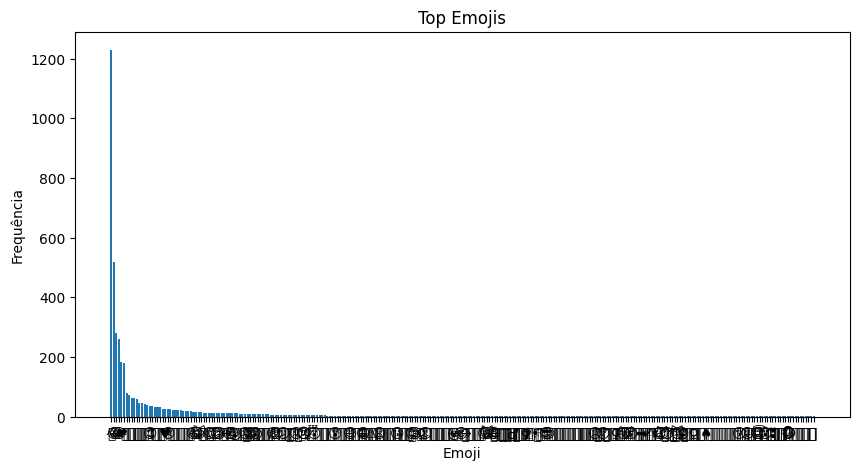

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(emoji_df["emoji"], emoji_df["count"])
plt.title("Top Emojis")
plt.xlabel("Emoji")
plt.ylabel("Frequência")
plt.show()

## 1. Detectar risadas (texto + emoji)

In [ ]:
import re

def is_laugh(message):
    msg = message.lower()

    return bool(
        re.search(r"\b(k){2,}\b", msg) or
        re.search(r"\b(ha){2,}\b", msg) or
        re.search(r"\b(rs){2,}\b", msg) or
        "😂" in msg or
        "🤣" in msg
    )

## 2. Filtrar só mensagens com risada

In [ ]:
df["is_laugh"] = df["message"].apply(is_laugh)

laugh_df = df[df["is_laugh"]]

## 3. Quem mais usa risada (total bruto)

In [ ]:
laugh_by_author = laugh_df["author"].value_counts()

laugh_by_author

,count
author,
Thor,1624
Zelda,691
Wanda,452
Altair,398
Leia,243
Raven,206
Neo,44
Mario,18
Kratos,11


<Axes: title={'center': 'Quem mais usa risadas'}, xlabel='author'>

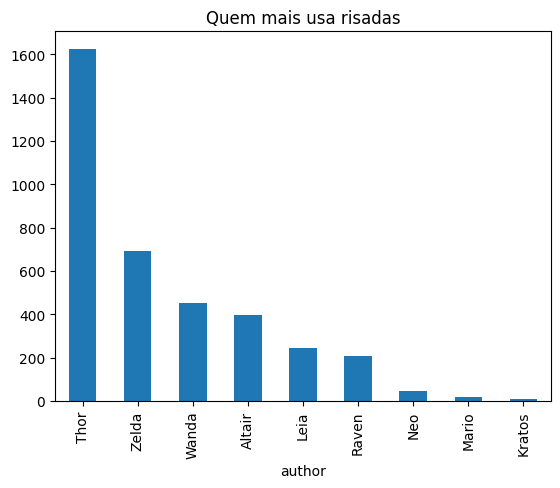

In [ ]:
laugh_by_author.plot(kind="bar", title="Quem mais usa risadas")

## 4. Quem mais usa proporcionalmente (isso que importa)

In [ ]:
total_msgs = df["author"].value_counts()

laugh_ratio = (laugh_by_author / total_msgs).sort_values(ascending=False)

laugh_ratio

,count
author,
Thor,0.162921
Leia,0.087222
Zelda,0.079709
Altair,0.063629
Wanda,0.059442
Raven,0.044531
Kratos,0.018519
Neo,0.015703
Mario,0.014839


<Axes: title={'center': 'Proporção de risadas por pessoa'}, xlabel='author'>

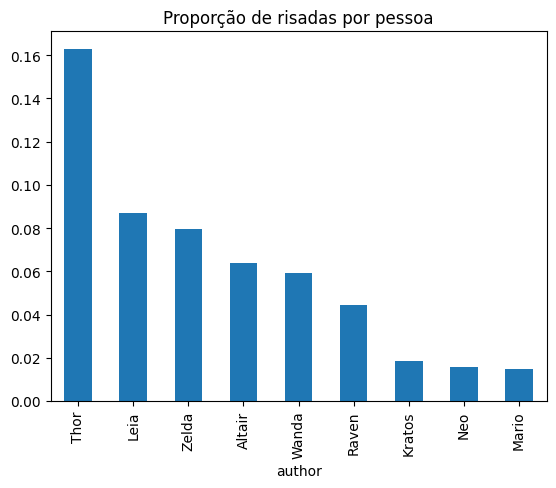

In [ ]:
laugh_ratio.plot(kind="bar", title="Proporção de risadas por pessoa")

## 5. Intensidade da risada (quem exagera)

In [ ]:
def laugh_intensity(msg):
    msg = msg.lower()
    return (
        len(re.findall(r"k", msg)) +
        len(re.findall(r"ha", msg)) +
        msg.count("😂") +
        msg.count("🤣")
    )

df["laugh_intensity"] = df["message"].apply(laugh_intensity)

intensity_by_author = df.groupby("author")["laugh_intensity"].mean().sort_values(ascending=False)

intensity_by_author

,laugh_intensity
author,
Thor,2.890951
Leia,1.482771
Zelda,1.426001
Altair,1.347242
Wanda,0.920700
Mario,0.807914
Raven,0.434717
Neo,0.295146
Kratos,0.237374


## 6. Tipos de risada (qual cada pessoa usa)

In [ ]:
def laugh_type(msg):
    msg = msg.lower()
    if "😂" in msg or "🤣" in msg:
        return "emoji"
    elif re.search(r"\b(k){2,}\b", msg):
        return "kkkk"
    elif re.search(r"\b(ha){2,}\b", msg):
        return "haha"
    elif re.search(r"\b(rs){2,}\b", msg):
        return "rs"
    return None

df["laugh_type"] = df["message"].apply(laugh_type)

laugh_types = df.dropna(subset=["laugh_type"])

laugh_types.groupby(["author", "laugh_type"]).size().unstack(fill_value=0)

laugh_type,emoji,haha,kkkk,rs
author,,,,
Altair,4,0,394,0
Kratos,1,10,0,0
Leia,14,0,229,0
Mario,0,0,18,0
Neo,0,2,42,0
Raven,50,0,156,0
Thor,106,7,1509,2
Wanda,311,2,139,0
Zelda,1,0,690,0


## Mensagens mais longas

In [ ]:
df["msg_length"] = df["message"].str.len()

top3 = df.nlargest(4, "msg_length")[["datetime", "author", "msg_length", "message"]]

top3

,datetime,author,msg_length,message
35273,2025-09-10 08:41:00,Mario,4075,"po @⁨Zelda⁩, parabens ai velho, de boa, muito ..."
4205,2024-10-27 19:21:00,Thor,2580,*SAFÁRI AMAZÔNICO*\n(Turismo Na Amazônia)\n🌳🐒🦥...
8961,2024-11-20 19:47:00,Altair,1500,KAKAAKKAKKAKAKAKAKAKAKKAKAKAKAKAKAKAKKAKAKAKAK...
37361,2025-10-21 09:14:00,Thor,1318,"Bom dia, Prefeito!\n​É um sonho ver o desenvol..."


In [ ]:
import pandas as pd

pd.set_option("display.max_colwidth", None)

top3

,datetime,author,msg_length,message
35273,2025-09-10 08:41:00,Mario,4075,"po @⁨Zelda⁩, parabens ai velho, de boa, muito legal isso. contei pra todos aqui da minha familia, todos acharam muito surpreendente e pediram pra te dar os parabens, queriam falar com você pessoalmente se possivel para lhe parabenizar. disseram também que na festa de natal irão contar para os parentes mais distantes e no ano novo lançarão baterias de fogos com seu nome. contei esse seu feito também para alguns outros parentes mais próximos, reagiram tal qual minha familia, pediram seu endereço para mandar cartões e mensagem de parabenização. meus amigos não acreditaram quando eu disse que conhecia o dono desse feito tão imenso, sério, ficaram todos de boca aberta, disseram que farão seu nome ecoar por anos e anos. quando os vizinhos ficaram sabendo do feito, ficaram todos boquiabertos, quiseram saber quem é você, pediu se, caso você tiver tempo, é claro, de poderia passar aqui para receber presentes, congratulações e apertos de mãos. com o esparrame da sua noticia, um grande empresario da região decidiu te contratar como presidente da empresa graças a esse seu surepreendente feito e ao mesmo tempo um grande acionista internacional quer patrocinar shows para você para palestrar e ensinar todos a fazerem igual para que o mundo seja um lugar melhor. você não só está famoso aqui na região quanto aí mas também em todas as partes, todos sabem quem é você graças ao rápido esparrame da notícia, prefeitos de todas as cidades estão pendurando faixas, balões, teleféricos, instalando aparelhos de som, tudo o que possa fazer seu nome vibrar para ver qual cidade te consagra mais por esse seu feito magnifico. aqui na minha cidade mesmo cada rua terá seu sobrenome a partir da próxima gestão da administração municipal. muitos países que antes viam o brasil com maus olhos, agora, graças ao seu feito, vêm o brasil como um exemplo, como uma nova capacitação, os grandes sortudos que sabem sobre você diz ""ei, aquele cara é brasileiro"" e todos replicam imediatamente ""é! é! é! o brasil é um bom lugar"". Graças a isso o turismo aumentou no brasil, todos vieram para cá graças a você, a entrada de moedas internacionais foi grande fazendo as bolsas e ações brasileiras decolarem e assim o brasil se tornou o pilar para solução da crise mundial. Graças a isso somos bem vistos e, claro, somos a maior potencia economica do mundo. todos os madeireiros se comoveram com seu feito e decidiram parar de explorar a amazonia para que o mundo viva mais e mais. o caos por conta do presidente paixão nos estados unidos foi cessado graças ao fato do brasil ser o lider economico mundial, uma vez sendo um país de varias etnias, todos passaram a aceitar as diferenças com amor no coração. o papa mandou todos os seus representantes pelo mundo falar sobre seu nome e sobre seus feitos para que a palavra sobre vossa pessoa chegue aos ouvidos de cada criatura que ande sobre a face desse planeta. Também, graças ao seu feito, decidiram cessar os experimentos com o LHC já que a origem do universo se torna sem importancia perto da magnitude desse seu ato. Os Maias voltaram de andromeda e disseram que como existe um humano tão magnifico vivo eles iriam dar a chance de nós sobrevivermos em 2012, contaram então sobre o que poderia causar o fim do mundo, e todos os lideres de todas as nações, inspirados nesse seu feito, estão tomando providencias para que não ocorra. a magnitude desse seu feito acabou até com o magnetismo que expulsou o corpo celeste alfa que habitava a órbita da terra. Em nome desse seu feito, Akira Toryama resolveu continuar com as sagas de dragon ball, desta vez com um personagem dedicado a você. Willian Bonner e Jô Soares ao se despedirem toda noite mandam uma saudação para o Brasil e uma somente para você. Continue sempre assim, essa pessoa linda, koshervilhosa, esforçada, inspiradora, magnifica, espitufenda, criativa, etc. E continue sempre fazendo atos como estes que o mundo será cada vez 

In [ ]:
import re
import unicodedata
from collections import Counter

bad_words = [
    "porra","caralho","cacete","puta","puto","merda",
    "fdp","foda","fodase","fodeu","desgraca","arrombado",
    "viado","buceta","cu","pqp","krl","vsf"
]

pattern = r"\b(" + "|".join(bad_words) + r")\b"

def normalize(text):
    return ''.join(
        c for c in unicodedata.normalize('NFD', text.lower())
        if unicodedata.category(c) != 'Mn'
    )

def extract_bad_words(text):
    return re.findall(pattern, text)

result = (
    df.assign(
        message_norm=lambda x: x["message"].apply(normalize),
        bad_words_list=lambda x: x["message_norm"].apply(extract_bad_words),
        bad_word_count=lambda x: x["bad_words_list"].apply(len),
        has_bad_word=lambda x: x["bad_word_count"] > 0
    )
    .groupby("author")
    .agg(
        total_msgs=("message", "count"),
        total_bad_words=("bad_word_count", "sum"),
        avg_bad_per_msg=("bad_word_count", "mean"),
        freq_bad_msgs=("has_bad_word", "mean"),
        most_common_bad_word=("bad_words_list", lambda lists: (
            Counter([w for sub in lists for w in sub]).most_common(1)[0][0]
            if any(lists) else None
        ))
    )
    .assign(
        bad_ratio=lambda x: x["total_bad_words"] / x["total_msgs"]
    )
    .sort_values("bad_ratio", ascending=False)
)

result

,total_msgs,total_bad_words,avg_bad_per_msg,freq_bad_msgs,most_common_bad_word,bad_ratio
author,,,,,,
Mario,1213,80,0.065952,0.064303,porra,0.065952
Leia,2786,125,0.044867,0.043790,porra,0.044867
Altair,6255,242,0.038689,0.037410,porra,0.038689
Wanda,7604,293,0.038532,0.036428,porra,0.038532
Zelda,8669,222,0.025608,0.023417,porra,0.025608
Thor,9968,180,0.018058,0.018058,cu,0.018058
Raven,4626,66,0.014267,0.012970,porra,0.014267
Neo,2802,29,0.010350,0.009636,viado,0.010350
Kratos,594,3,0.005051,0.005051,merda,0.005051
